In [1]:
from spubase.data_access import Particles
import pandas as pd

# Initialize SpuBase

In [2]:
SpuBase = Particles(verbose=True, show_plot=False)  # create object (acts as 'self' and is used to call globals)

Model: sbbx
SW fraction is 96% H+ and 4% He2+
DB directory: C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\docs


#### Data

In [3]:
oxide_comp_df = pd.read_csv('../input/Lunar_compositions.csv', index_col='sample')
SpuBase.casename = oxide_comp_df.index.tolist()[0]  # for demonstration purposes we only run the first composition

#### Optional Inputs

In [4]:
# SpuBase.update_file_format('pdf') # plot format, choose between 'pdf', 'png', 'svg', 'tiff'
# SpuBase.update_impactor('H', comp_frac=[1.00, 0.00])  # either 1 keV H ('H'), 4 keV He ('He') or both ('SW'); comp_frac: different mixture of H, He (Significantly effects yield and angular distribution!)
# SpuBase.sulfur_diffusion = False  # turns off S diffusion in sulfides (gets turned off automatically if impactor != 'SW')
# SpuBase.v_esc = 2380 # m/s  escape velocity of irradiated body
# SpuBase.return_amu_ion = True  # plot total mass yield in amu/ion instead of atomic yields
# SpuBase.is_summed_up = False  # return result for each individual species separately instead of summing components

#### Change ouput directory to DATABASE/output/casename

In [5]:
SpuBase.update_directory()

Directory already exists:
C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Mare Basalt


#### Get mineral composition with CIPW norm

In [6]:
SpuBase.update_directory()  #creates a directory in output/SpuBase.casename

at_l = oxide_comp_df.columns.tolist()
at_frac = oxide_comp_df.loc[SpuBase.casename].tolist()

minfrac_volume = SpuBase.cipw_norm(at_l, at_frac)

SpuBase.surfcomp()

Directory already exists:
C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Mare Basalt
Composition given as oxides: False
Composition with > 47 % oxygen - at% assumed
Transition metals are attributed to Sulfur (3.87e-05)

spubase modal abundances (vol%):
         frac
Ab   0.041994
Abd  0.000026
An   0.324852
Chr  0.000032
Di   0.246732
En   0.119502
Fs   0.100311
Ilm  0.143925
Or   0.000051
Qz   0.022559
Tro  0.000017
Total: 1.00

Sum of mineral data available in SpuBase is 1.00/1.00



In [7]:
print('CIPW form:\n{}'.format(SpuBase.minfrac_df_volume_CIPW.T))

CIPW form:
           Abd       Chr        Di       Ilm       Opx        Or      Plag  \
frac  0.000026  0.000032  0.247947  0.144633  0.221621  0.000052  0.363001   

           Qz       Tro  
frac  0.02267  0.000017  


#### Create DataFrame based on input

In [8]:
SpuBase.dataseries()


Sum up particles from minerals and perform a re-fit
Process:
8.3% O
16.7% Na
25.0% Mg
33.3% Al
41.7% Si
50.0% Ti
58.3% K
66.7% Ca
75.0% Fe
83.3% Cr
91.7% S
100.0% Mn
Data exported as .csv to C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Mare Basalt\SW_Mare Basalt_particle_data.txt
Data for Mare Basalt created



In [9]:
SpuBase.yield_df  # yield gets written into the output file together with the particle angular and energy fit parameter

,O,Na,Mg,Al,Si,Ti,K,Ca,Fe,Cr,S,Mn
alpha,,,,,,,,,,,,
0.0,0.009078,0.000048,0.000773,0.000746,0.002556,0.000439,5.602945e-08,0.000803,0.000764,1.744509e-07,1.346387e-08,9.005850e-07
1.0,0.009082,0.000048,0.000774,0.000747,0.002557,0.000439,5.605470e-08,0.000803,0.000764,1.745099e-07,1.346734e-08,9.008695e-07
2.0,0.009094,0.000048,0.000775,0.000748,0.002560,0.000439,5.612602e-08,0.000804,0.000765,1.746823e-07,1.347827e-08,9.016887e-07
3.0,0.009113,0.000048,0.000776,0.000750,0.002565,0.000440,5.624127e-08,0.000806,0.000766,1.749659e-07,1.349697e-08,9.030255e-07
4.0,0.009138,0.000048,0.000778,0.000752,0.002572,0.000441,5.639957e-08,0.000808,0.000768,1.753600e-07,1.352365e-08,9.048730e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
84.0,0.086594,0.000503,0.007863,0.007679,0.024310,0.002946,6.140633e-07,0.007507,0.005555,9.548667e-07,1.444994e-07,3.719133e-06
85.0,0.068915,0.000408,0.006386,0.006072,0.019472,0.002206,5.042291e-07,0.005992,0.004264,6.904677e-07,9.630285e-08,2.829409e-06
86.0,0.046600,0.000284,0.004421,0.004116,0.013197,0.001335,3.555391e-07,0.004037,0.002684,3.947194e-07,4.011074e-08,1.790787e-06


#### Plot data

Plotting yield


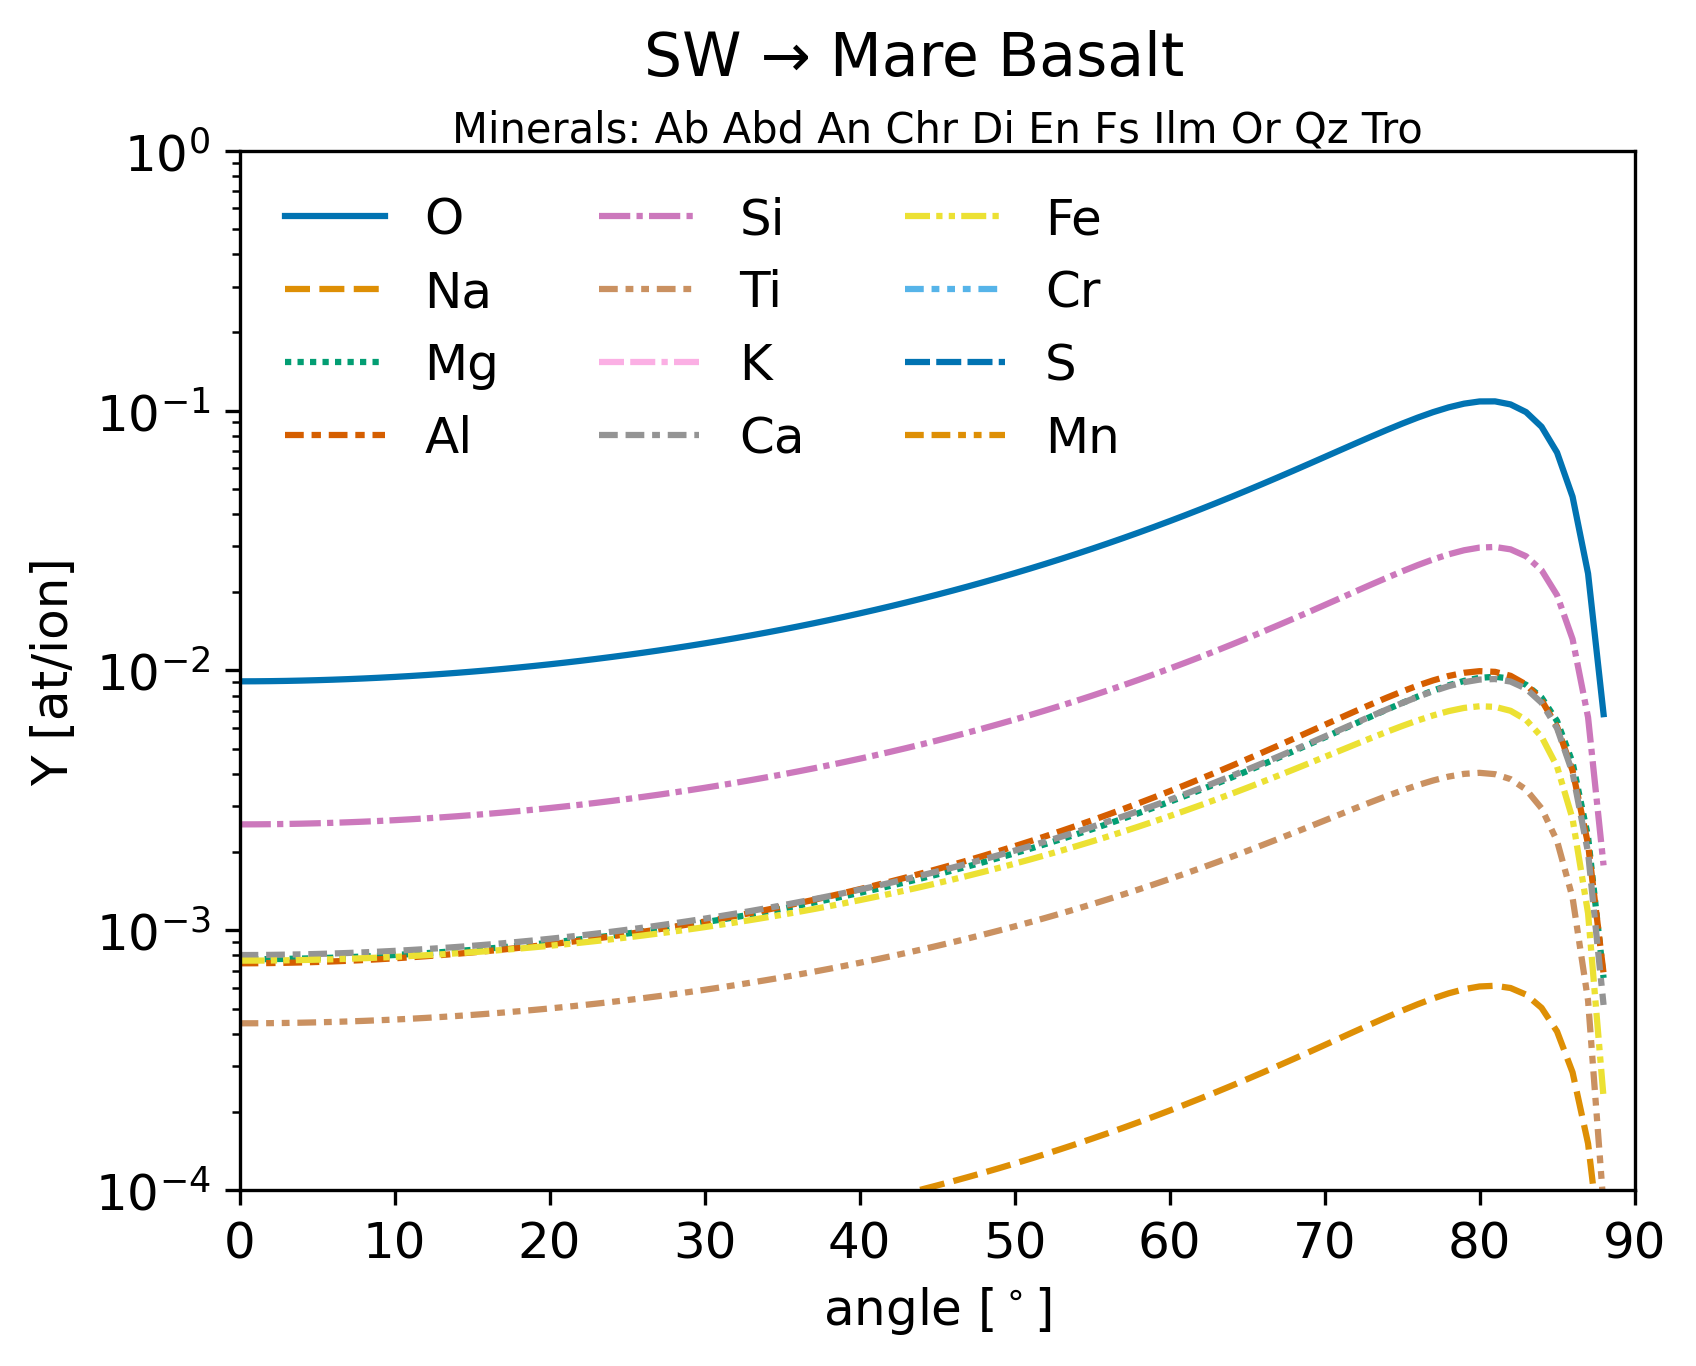

In [10]:
fig, ax = SpuBase.plot_yield()
fig

In [11]:
SpuBase.dist_angle = 45 # set distribution angle (default: 45°)
SpuBase.sputtered_particles_data()

Plotting angular distribution


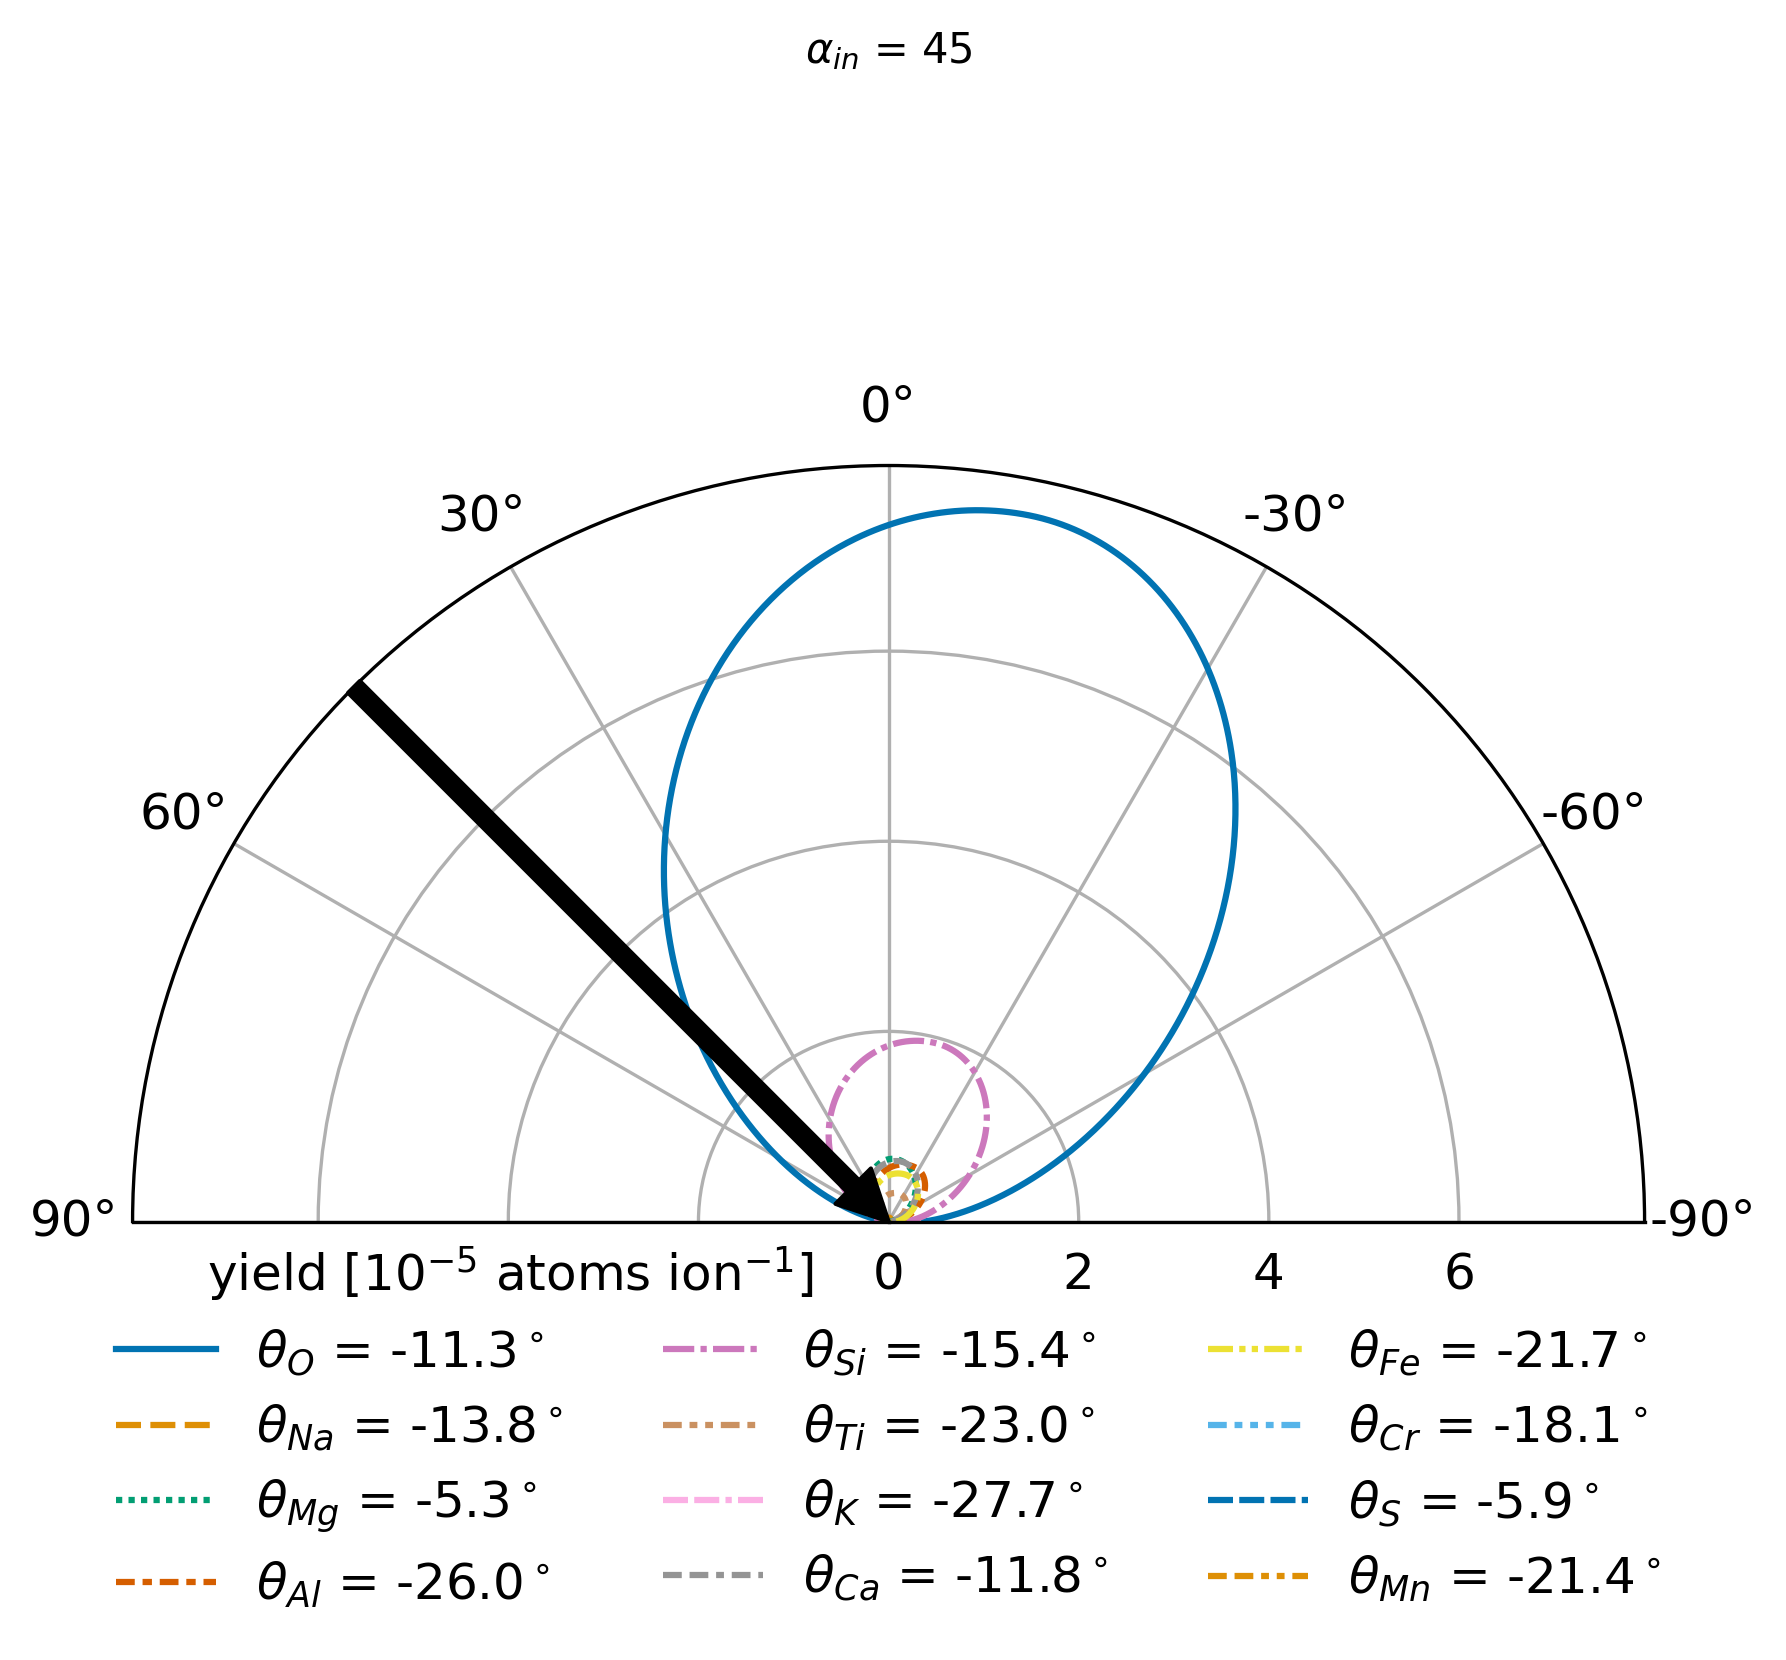

In [12]:
fig_adist, ax_adist = SpuBase.plot_dist('angular', title='')
fig_adist

Plotting energy distribution


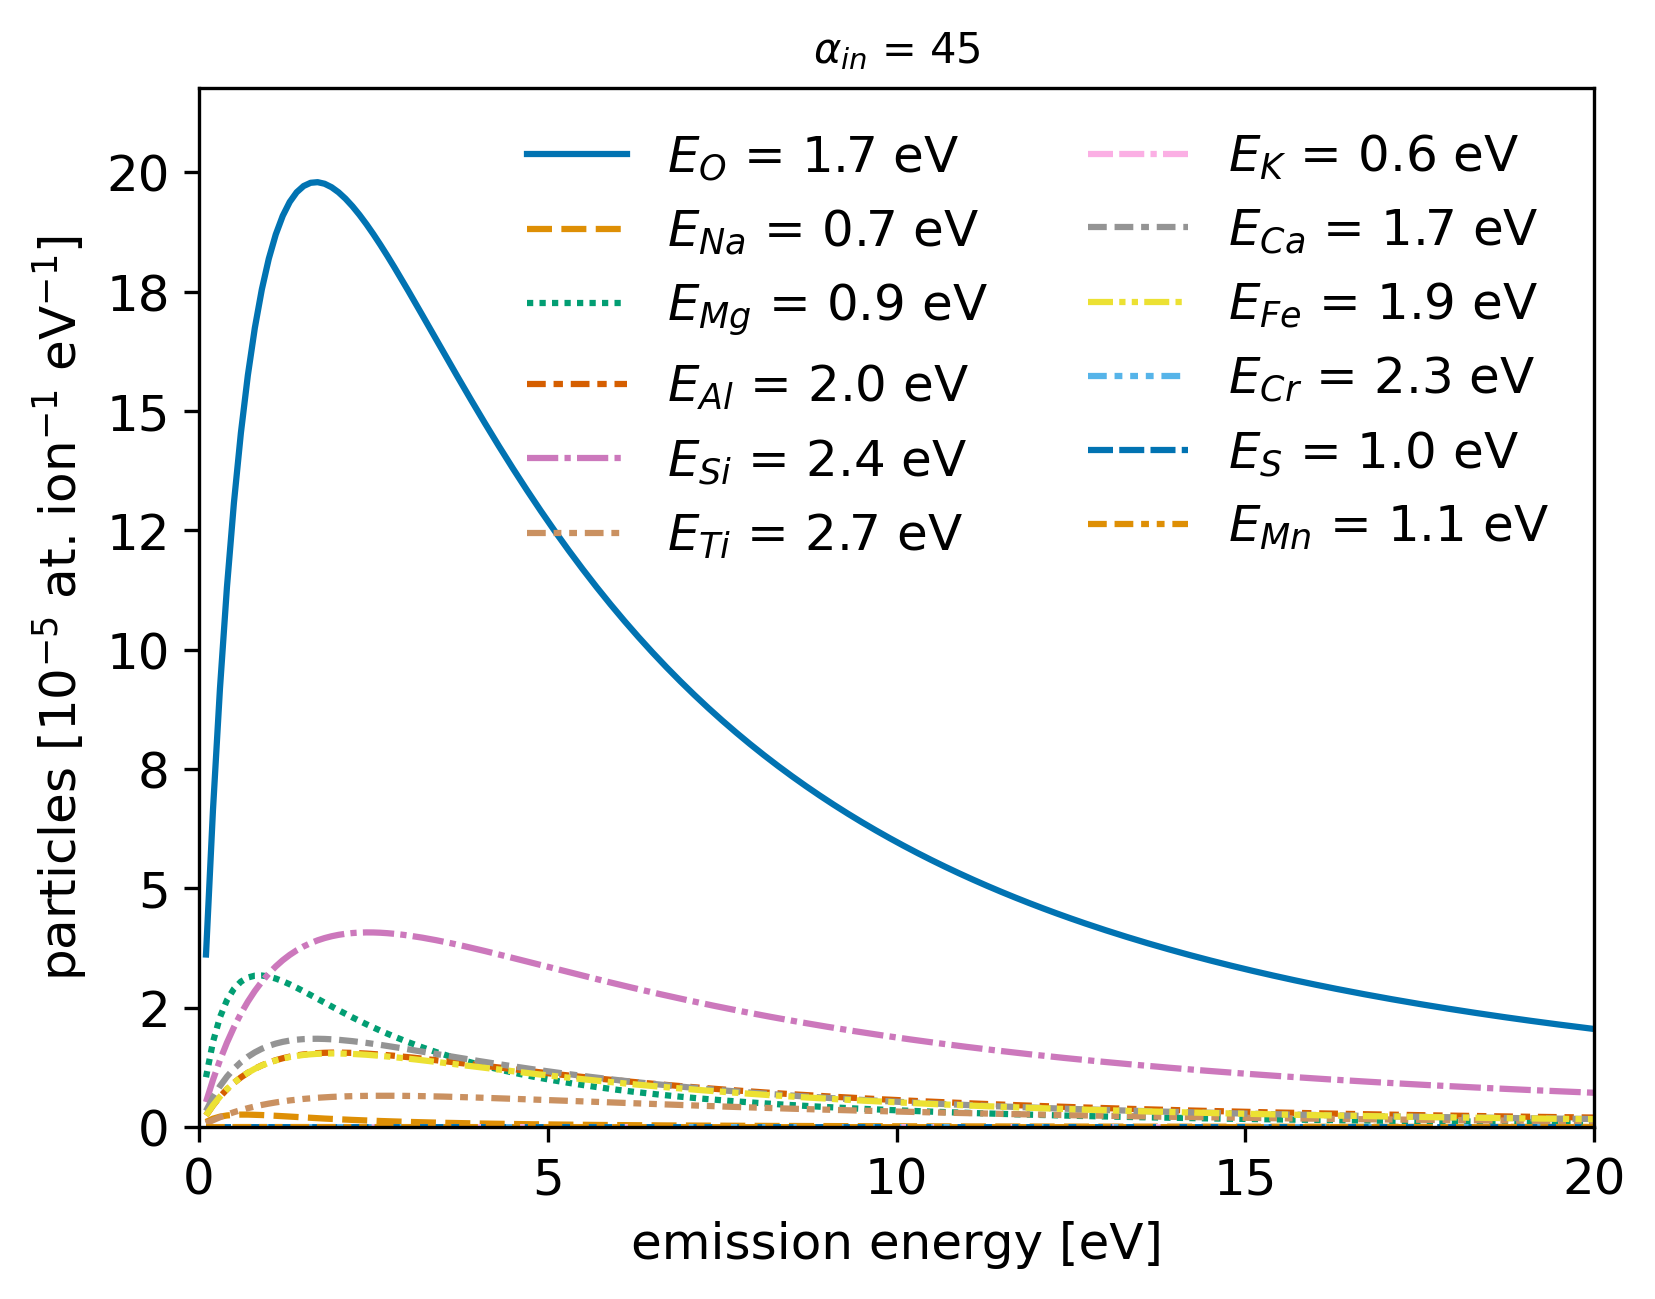

In [13]:
fig_edist, ax_edist = SpuBase.plot_dist('energy', title='')
fig_edist